# DistributedCircuit Intermediate Representation

This notebook demonstrates the `DistributedCircuit` abstraction that sits between the
partitioned hypergraph and any concrete output format (Qiskit, QASM, QPIC, ...).

Instead of immediately emitting EPR generation and classical correction instructions,
the intermediate representation captures the **structure** of distributed communication:

| Event | Meaning |
|---|---|
| `LocalGate` | Gate entirely within one partition |
| `StateTransfer` | Qubit moves between partitions (assignment change) |
| `FanOut` | Root qubit fanned out along a network tree to target + intermediate partitions |
| `ImmediateFanIn` | Routing-only intermediate nodes fanned in straight after FanOut |
| `LinkedGate` | Gate applied while root qubit is spread across partitions |
| `FanIn` | One live copy fanned in when no longer needed |

The intermediate circuit can then be rendered as a **QPIC diagram** using `START`/`END`
annotations to show fan-out and fan-in visually.

## 1. Build circuit and hypergraph

In [26]:
from disqco.circuits.cp_fraction import cp_fraction
from disqco import QuantumCircuitHyperGraph, QuantumNetwork
from qiskit import transpile

num_qubits = 6

circuit = cp_fraction(num_qubits=num_qubits, depth=12, fraction=0.5, seed=52345)
circuit = transpile(circuit, basis_gates=['u', 'cx'])

num_partitions = 4
qpu_size = num_qubits // num_partitions + 1
qpu_info = [qpu_size] * num_partitions

qnet = QuantumNetwork(qpu_info, qpu_connectivity=[(0, 1), (1, 2), (2, 3)])

graph = QuantumCircuitHyperGraph(circuit=circuit, group_gates=True, anti_diag=True)

print(f"Circuit: {num_qubits} qubits, depth {circuit.depth()}")
print(f"Network: {num_partitions} QPUs of size {qpu_size}")

Circuit: 6 qubits, depth 33
Network: 4 QPUs of size 2


## 2. Optimise the partition assignment

Best e-bit cost: 8


<Axes: >

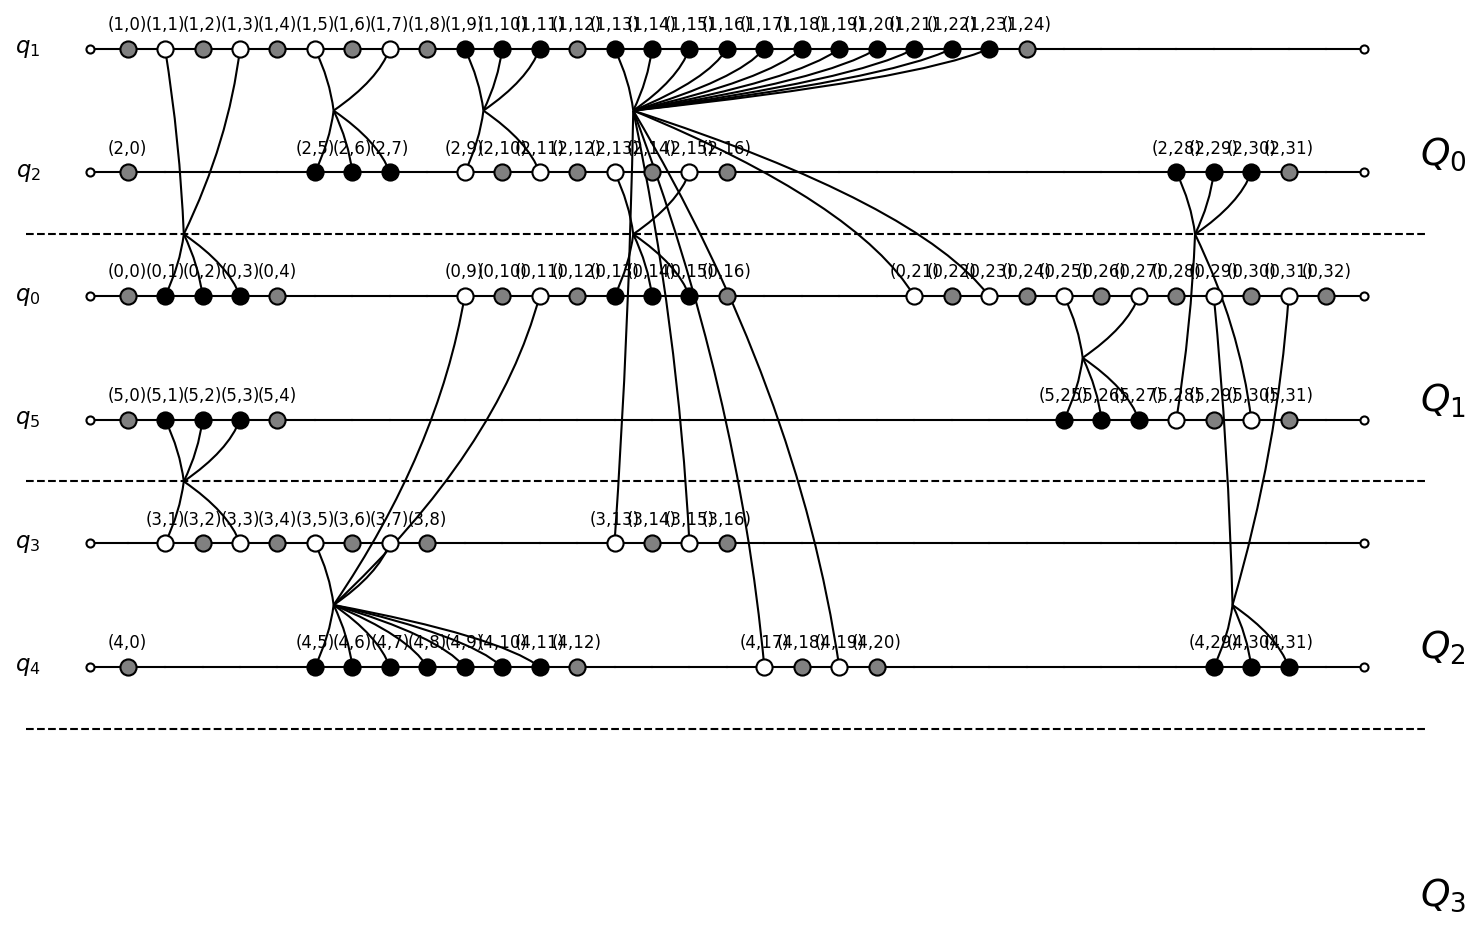

In [27]:
from disqco.parti import FiducciaMattheyses
from disqco import set_initial_partition_assignment

assignment = set_initial_partition_assignment(graph=graph, network=qnet)

partitioner = FiducciaMattheyses(
    circuit=circuit,
    network=qnet,
    partition_assignment=assignment,
    hypergraph=graph,
)

results = partitioner.multilevel_partition()
assignment = results['best_assignment']

print(f"Best e-bit cost: {results['best_cost']}")
graph.draw(network=qnet, assignment=assignment, output='mpl')

## 3. Build the DistributedCircuit

`HypergraphToDistributed` traverses the partitioned hypergraph and emits abstract events.
No Qiskit circuit is produced at this stage — only the communication structure.

In [28]:
from disqco.circuit_extraction import HypergraphToDistributed

builder = HypergraphToDistributed(graph, qnet, assignment)
dc = builder.build()

print(dc.summary())



DistributedCircuit (6q, 4p):
  FanIn: 8
  FanOut: 7
  LinkedGate: 26
  LocalGate: 41


### Inspect events by type

In [29]:
from disqco.circuit_extraction import FanOut, ImmediateFanIn, FanIn, LinkedGate, StateTransfer

fan_outs   = dc.get_events_by_type(FanOut)
imm_fi     = dc.get_events_by_type(ImmediateFanIn)
fan_ins    = dc.get_events_by_type(FanIn)
linked     = dc.get_events_by_type(LinkedGate)
transfers  = dc.get_events_by_type(StateTransfer)

print(f"FanOut events      : {len(fan_outs)}")
print(f"ImmediateFanIn     : {len(imm_fi)}")
print(f"FanIn events       : {len(fan_ins)}")
print(f"LinkedGate events  : {len(linked)}")
print(f"StateTransfer      : {len(transfers)}")

FanOut events      : 7
ImmediateFanIn     : 0
FanIn events       : 8
LinkedGate events  : 26
StateTransfer      : 0


In [30]:
# Print each FanOut to show the path tree and target partitions
for fo in fan_outs:
    print(f"  FanOut  q{fo.root_qubit}  p{fo.root_partition} → targets={fo.target_partitions}",
          f"  intermediates={fo.intermediate_partitions}  t={fo.time}")
    print(f"    tree edges: {list(fo.path_tree.edges())}")

  FanOut  q0  p1 → targets=[0]   intermediates=[]  t=1
    tree edges: [(1, 0)]
  FanOut  q5  p1 → targets=[2]   intermediates=[]  t=1
    tree edges: [(1, 2)]
  FanOut  q4  p2 → targets=[1]   intermediates=[]  t=5
    tree edges: [(2, 1)]
  FanOut  q0  p1 → targets=[0]   intermediates=[]  t=13
    tree edges: [(1, 0)]
  FanOut  q1  p0 → targets=[1, 2]   intermediates=[]  t=13
    tree edges: [(0, 1), (1, 2)]
  FanOut  q2  p0 → targets=[1]   intermediates=[]  t=28
    tree edges: [(0, 1)]
  FanOut  q4  p2 → targets=[1]   intermediates=[]  t=29
    tree edges: [(2, 1)]


In [31]:
# Print each FanIn
for fi in fan_ins:
    print(f"  FanIn   q{fi.root_qubit}  p{fi.source_partition} → p{fi.target_partition}  t={fi.time}")

  FanIn   q0  p0 → p1  t=3
  FanIn   q5  p2 → p1  t=3
  FanIn   q4  p1 → p2  t=11
  FanIn   q0  p0 → p1  t=15
  FanIn   q1  p2 → p0  t=19
  FanIn   q1  p1 → p0  t=23
  FanIn   q2  p1 → p0  t=30
  FanIn   q4  p1 → p2  t=31


In [32]:
# Print all events in order
print("All events (in order):\n")
for event in dc.events:
    print(f"  {type(event).__name__:20s}  {event}")

All events (in order):

  LocalGate             LocalGate(gate_name='u', params=[1.161856499666678, 0.45244056257800347, 1.5957164773629149], qubits=[(0, 1)], time=0)
  LocalGate             LocalGate(gate_name='u', params=[0.05035489459739371, 1.625395094958411, 1.811722232063859], qubits=[(1, 0)], time=0)
  LocalGate             LocalGate(gate_name='u', params=[0.0, 0.0, 2.1725996765542335], qubits=[(2, 0)], time=0)
  LocalGate             LocalGate(gate_name='u', params=[1.2348483571146656, 2.152678922373921, 3.006013894602214], qubits=[(4, 2)], time=0)
  LocalGate             LocalGate(gate_name='u', params=[0.0, 0.0, 0.894839428168576], qubits=[(5, 1)], time=0)
  FanOut                FanOut(root_qubit=0, root_partition=1, path_tree=<networkx.classes.digraph.DiGraph object at 0x126baf8b0>, target_partitions=[0], intermediate_partitions=[], time=1, final_root_partition=1)
  LinkedGate            LinkedGate(gate_name='cx', params=[], root_qubit=0, root_partition=0, target_qubit=1, t

### Wire IDs

Each `(qubit_index, partition)` pair that appears in any event becomes a wire in the
QPIC diagram.  Qubits that never leave their initial partition have only one wire;
qubits involved in fan-out have one wire per partition they visit.

In [33]:
wires = dc.qubit_wire_ids()
print(f"Total wires (qubit, partition pairs): {len(wires)}")
for q, p in sorted(wires):
    print(f"  q{q}p{p}")

Total wires (qubit, partition pairs): 12
  q0p0
  q0p1
  q1p0
  q1p1
  q1p2
  q2p0
  q2p1
  q3p2
  q4p1
  q4p2
  q5p1
  q5p2


## 4. Render to QPIC

`DistributedCircuitQPIC` converts the event sequence to a QPIC text diagram.

- `FanOut` → new wires `START` together, labelled `FO`
- `ImmediateFanIn` → intermediate wires `END` together, labelled `IFI`
- `FanIn` → source wire `END`, labelled `FI`
- `StateTransfer` → source wire `END`, target wire `START`
- Gates → standard QPIC gate notation

In [34]:
from disqco.drawing import DistributedCircuitQPIC

renderer = DistributedCircuitQPIC(dc, draw_qpu_boundaries=True, qpu_boundary_fills=['red','teal'])
qpic_str = renderer.to_qpic_string()
print(qpic_str)

q1p0 W q_{1}^{(0)}
q2p0 W q_{2}^{(0)}
c0_0 W q_{0}^{(0)}
gap_p0 W type=o
q0p1 W q_{0}^{(1)}
q5p1 W q_{5}^{(1)}
c1_0 W q_{4}^{(1)} {} q_{1}^{(1)} {} q_{2}^{(1)}
c1_1 W q_{4}^{(1)}
gap_p1 W type=o
q3p2 W q_{3}^{(2)}
q4p2 W q_{4}^{(2)}
c2_0 W q_{5}^{(2)} {} q_{1}^{(2)}
gap_p2 W type=o
q1p0 c0_0 @ 0 30 color=black style=dashed,rounded_corners=5pt,fill=red
q0p1 c1_1 @ 0 30 color=black style=dashed,rounded_corners=5pt,fill=teal
q3p2 c2_0 @ 0 30 color=black style=dashed,rounded_corners=5pt,fill=red

q0p1 G $U$ ; q1p0 G $U$ ; q2p0 G $U$ ; q4p2 G $U$ ; q5p1 G $U$
% FanOut q0 p1 -> targets [0] intermediates []
% FanOut q5 p1 -> targets [2] intermediates []
% FanOut q4 p2 -> targets [1] intermediates []
q0p1 c0_0 starting ; q5p1 c2_0 starting ; q4p2 c1_0 starting
+q1p0 c0_0 ; +q3p2 c2_0
q1p0 G $U$ ; q3p2 G $U$
+q1p0 c0_0 ; +q3p2 c2_0
% FanIn q0 p0->p1
% FanIn q5 p2->p1
q0p1 c0_0 ending ; q5p1 c2_0 ending ; q1p0 G $U$ ; q3p2 G $U$
q0p1 G $U$ ; q5p1 G $U$ ; +q1p0 q2p0 ; +q3p2 q4p2
q1p0 G $U$ ; q3p2

In [35]:
# Save to file so it can be compiled with the qpic tool
output_path = "distributed_circuit.qpic"
renderer.to_qpic_file(output_path)
print(f"Written to {output_path}")
print("Compile with:  python -m qpic distributed_circuit.qpic > distributed_circuit.tex")

Written to distributed_circuit.qpic
Compile with:  python -m qpic distributed_circuit.qpic > distributed_circuit.tex


In [36]:
renderer.to_qpic_file_lowered(path="distributed_circuit_lowered.qpic")


### Compile and display (requires qpic and pdflatex)

The cell below compiles the QPIC file to a PNG and displays it inline.
Skip if the tools are not available.

In [37]:
import subprocess, shutil
from IPython.display import Image, display

if shutil.which('pdflatex') is not None:
    result = subprocess.run(
        ['python', '-m', 'qpic', '-f', 'png', '-o', 'distributed_circuit.png', output_path],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        display(Image('distributed_circuit.png'))
    else:
        print("qpic compilation failed:")
        print(result.stderr)
else:
    print("pdflatex not found — skipping compilation.")
    print("Install LaTeX and run: python -m qpic -f png -o distributed_circuit.png distributed_circuit.qpic")

qpic compilation failed:
/Users/ftb123/anaconda3/envs/disqco_env/bin/python: No module named qpic



/Users/ftb123/anaconda3/envs/disqco_env/lib/python3.13/site-packages/qiskit/circuit/quantumcircuit.py:3394: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


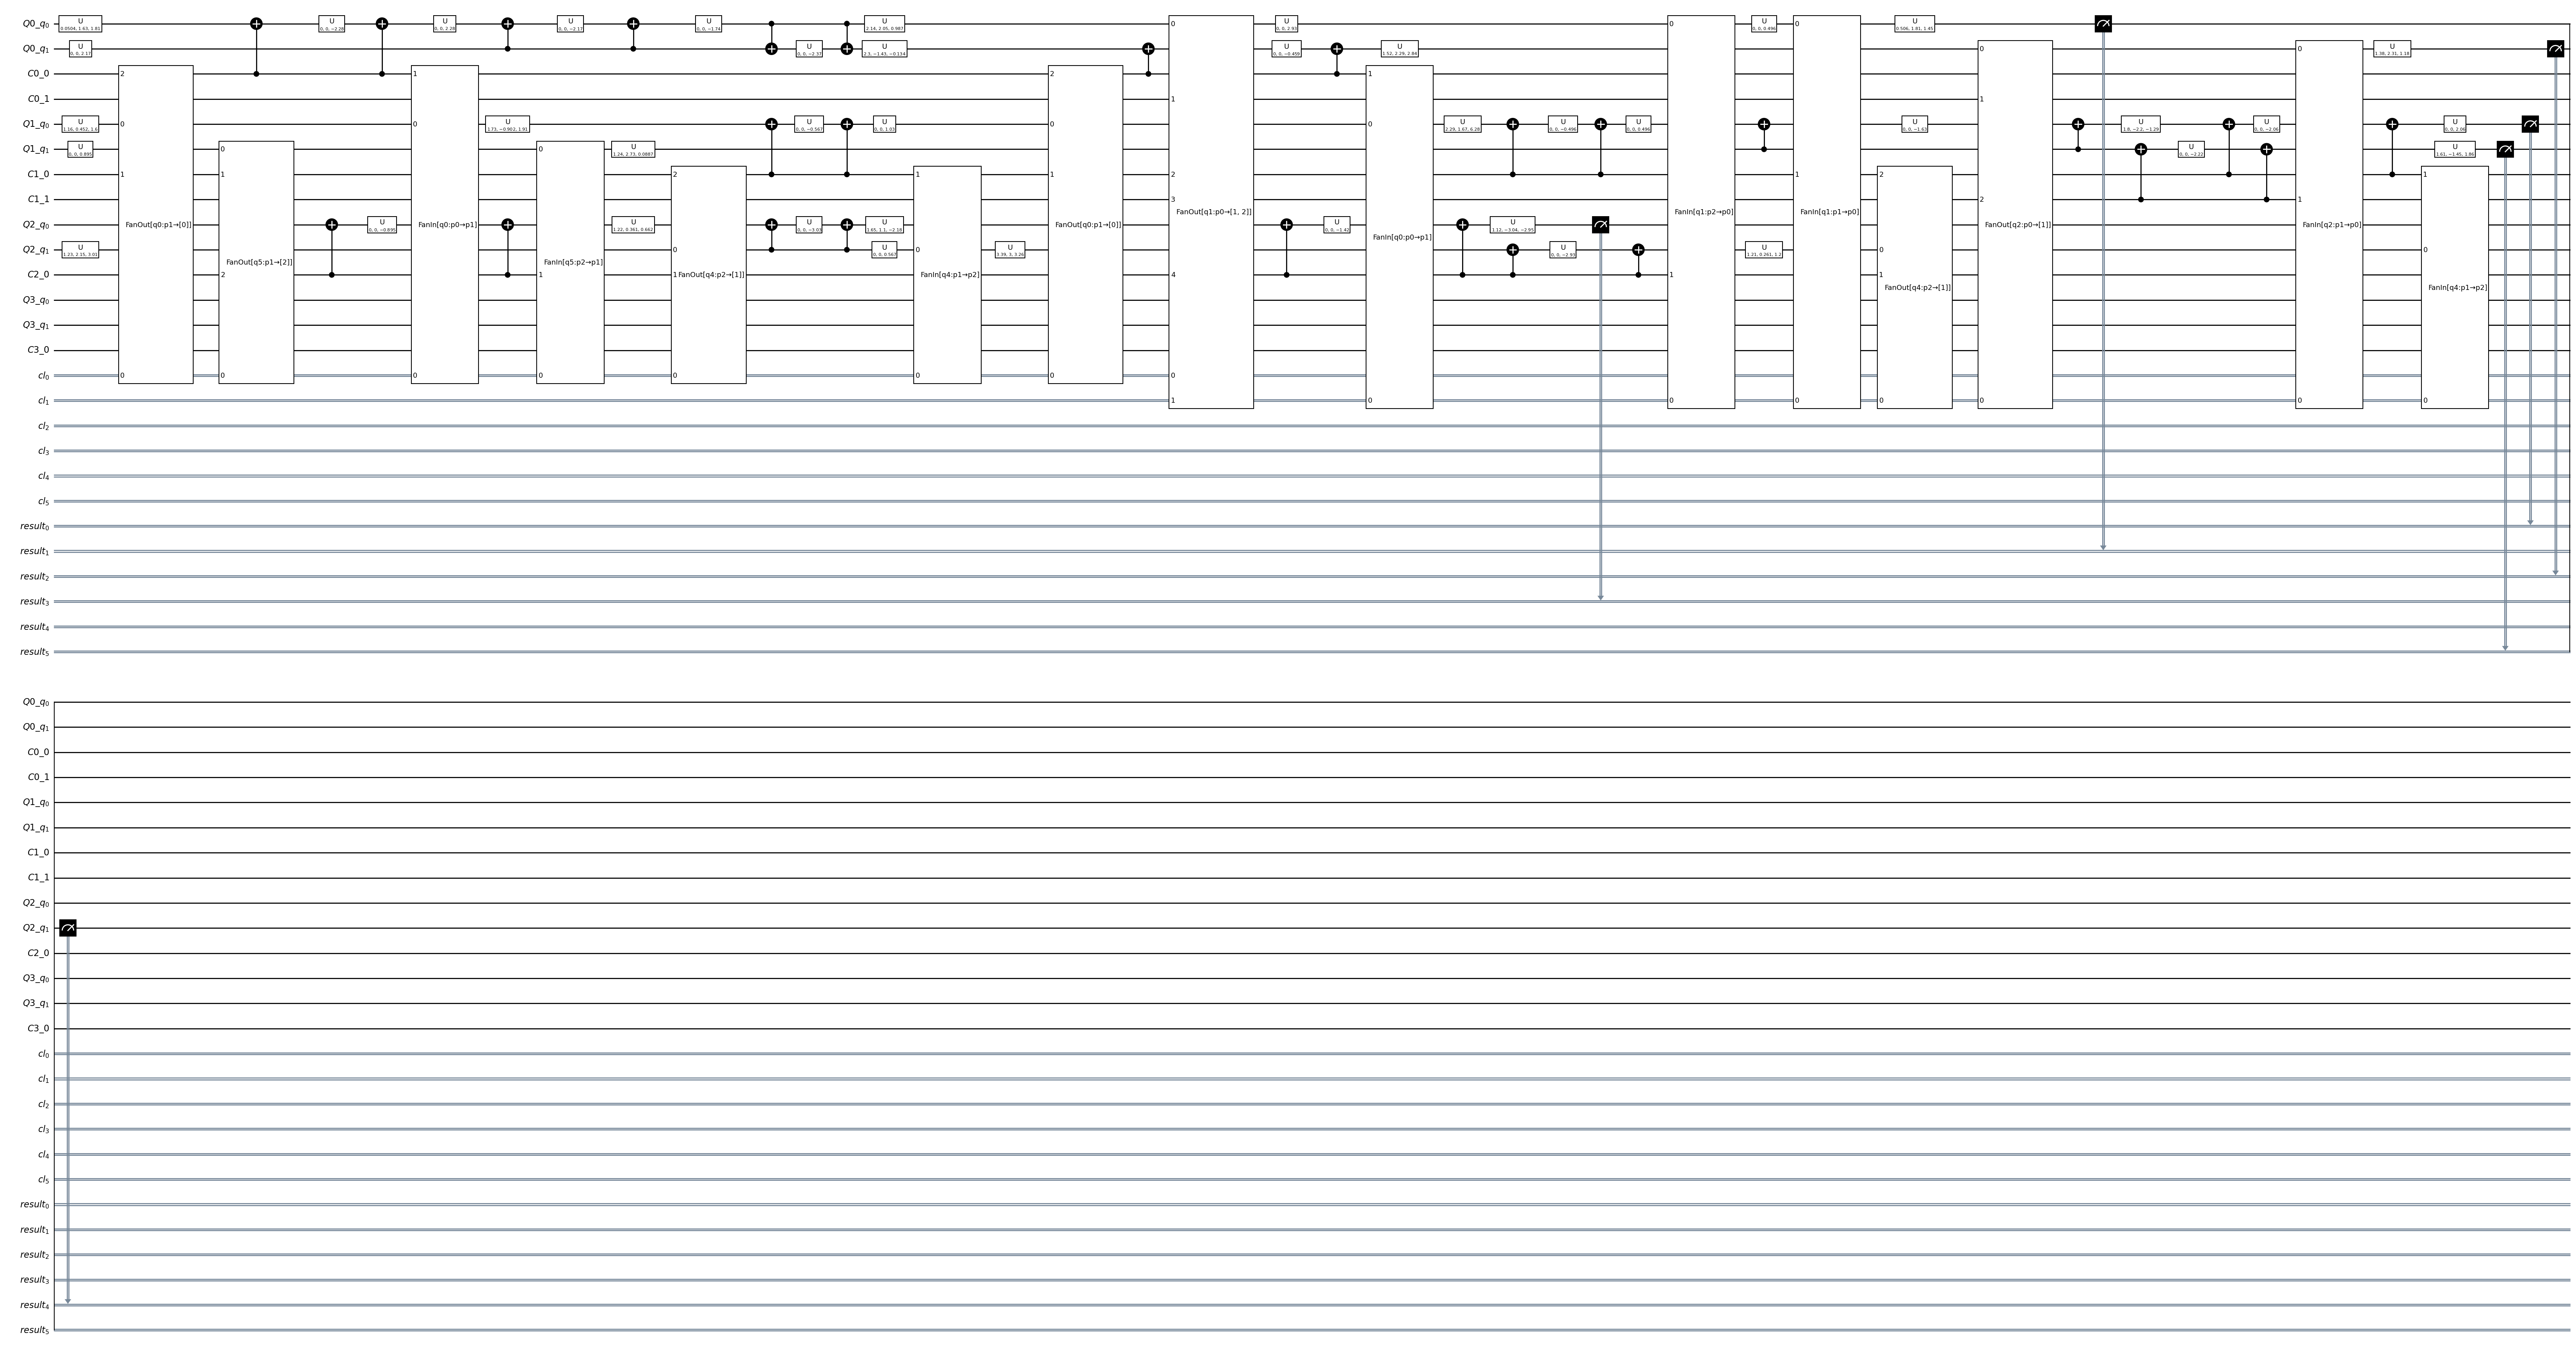

In [38]:
from disqco.circuit_extraction.distributed_to_qiskit import DistributedCircuitToQiskit

lowerer = DistributedCircuitToQiskit(dc, qnet, assignment[0], compress_corrections=False)
dc_qiskit = lowerer.build()

dc_qiskit.draw(output='mpl', style='bw', fold=100)

## 5. Compare with the full Qiskit extraction

The `PartitionedCircuitExtractor` (existing API, unchanged) still produces the
fully concrete Qiskit circuit with EPR gates and classical corrections.

In [39]:
from disqco import PartitionedCircuitExtractor

extractor = PartitionedCircuitExtractor(graph=graph, network=qnet,
                                        partition_assignment=assignment)
qiskit_circuit = extractor.extract_partitioned_circuit()

qiskit_epr = transpile(qiskit_circuit, basis_gates=['cp', 'u', 'EPR'])
epr_count = qiskit_epr.count_ops().get('EPR', 0)

print(f"Qiskit circuit depth : {qiskit_circuit.depth()}")
print(f"EPR pairs required   : {epr_count}")
print()
print("DistributedCircuit fan-out/fan-in summary:")
print(f"  FanOut events  = {len(fan_outs)}  (each becomes ≥1 EPR pair)")
print(f"  FanIn events   = {len(fan_ins)}")

Qiskit circuit depth : 56
EPR pairs required   : 8

DistributedCircuit fan-out/fan-in summary:
  FanOut events  = 7  (each becomes ≥1 EPR pair)
  FanIn events   = 8


In [40]:
# Verification test for this notebook example (sampler overlap, no small-qubit cutoff)
from qiskit import transpile
from qiskit_aer.primitives import SamplerV2
from disqco.circuit_extraction.verification import get_fidelity

shots = 2048
sampler = SamplerV2()


def run_sampler_no_limit(circ, shots=2048):
    c = circ.copy()
    c = transpile(c, basis_gates=['u', 'cp', 'EPR'])
    c = c.decompose()
    job = sampler.run([c], shots=shots)
    return job.result()[0].data


base_for_verification = circuit.copy()
base_for_verification.measure_all()

data_base = run_sampler_no_limit(base_for_verification, shots=shots)
data_partitioned = run_sampler_no_limit(qiskit_circuit, shots=shots)

verification_fidelity = get_fidelity(data_base, data_partitioned, shots=shots)
print(f"Verification fidelity (sampler overlap, shots={shots}): {verification_fidelity:.10f}")

Verification fidelity (sampler overlap, shots=2048): 0.9749717712


In [41]:
# Bounded overlap metrics for interpretation
from qiskit.result import sampled_expectation_value


def _counts_from_data(data):
    if 'result' in data:
        return data['result'].get_counts()
    if 'meas' in data:
        return data['meas'].get_counts()
    if 'measure' in data:
        return data['measure'].get_counts()
    return {}


counts_base = _counts_from_data(data_base)
counts_part = _counts_from_data(data_partitioned)

all_keys = set(counts_base) | set(counts_part)
p = {k: counts_base.get(k, 0) / shots for k in all_keys}
q = {k: counts_part.get(k, 0) / shots for k in all_keys}

l1 = sum(abs(p[k] - q[k]) for k in all_keys)
tv_similarity = 1 - 0.5 * l1
bhattacharyya = sum((p[k] * q[k]) ** 0.5 for k in all_keys)

print(f"TV-based similarity (1 - TV distance): {tv_similarity:.10f}")
print(f"Bhattacharyya overlap:               {bhattacharyya:.10f}")

TV-based similarity (1 - TV distance): 0.9208984375
Bhattacharyya overlap:               0.9901424794


In [42]:
# # Channel/process fidelity check (compact validation case to keep memory bounded)
# import numpy as np
# from qiskit import QuantumCircuit, QuantumRegister
# from qiskit.quantum_info import DensityMatrix, Statevector, partial_trace, state_fidelity
# from qiskit_aer import AerSimulator
# from disqco import QuantumCircuitHyperGraph, QuantumNetwork, PartitionedCircuitExtractor, set_initial_partition_assignment


# def choi_state_fidelity(base_circuit, extractor, partitioned_circuit):
#     simulator = AerSimulator(method='density_matrix')
#     num_logical = base_circuit.num_qubits

#     stripped = partitioned_circuit.remove_final_measurements(inplace=False)
#     stripped = transpile(stripped, basis_gates=['u', 'cx'], optimization_level=0)

#     input_map = extractor.qubit_manager.inital_qubit_placement
#     output_map = extractor.qubit_manager.log_to_phys_idx

#     input_indices = [partitioned_circuit.find_bit(input_map[i]).index for i in range(num_logical)]
#     output_indices = [partitioned_circuit.find_bit(output_map[i]).index for i in range(num_logical)]

#     ref = QuantumRegister(num_logical, name='ref')
#     full = QuantumCircuit(ref, *stripped.qregs, *stripped.cregs)

#     for i in range(num_logical):
#         full.h(ref[i])
#         full.cx(ref[i], full.qubits[num_logical + input_indices[i]])

#     full.compose(stripped, qubits=full.qubits[num_logical:], clbits=full.clbits, inplace=True)
#     full.save_density_matrix()

#     rho_full = DensityMatrix(simulator.run(full).result().data(0)['density_matrix'])

#     keep_bits = [full.qubits[i] for i in range(num_logical)] + [
#         full.qubits[num_logical + idx] for idx in output_indices
#     ]
#     trace_out = [idx for idx, bit in enumerate(full.qubits) if bit not in keep_bits]
#     rho_reduced = partial_trace(rho_full, trace_out)

#     ideal = QuantumCircuit(2 * num_logical)
#     for i in range(num_logical):
#         ideal.h(i)
#         ideal.cx(i, num_logical + i)
#     ideal.compose(base_circuit, qubits=list(range(num_logical, 2 * num_logical)), inplace=True)
#     rho_ideal = DensityMatrix(Statevector.from_instruction(ideal))

#     return state_fidelity(rho_reduced, rho_ideal)


# # Small, non-local circuit for exact channel verification
# validation_circuit = QuantumCircuit(3)
# validation_circuit.h(0)
# validation_circuit.h(1)
# validation_circuit.cp(np.pi / 3, 1, 2)
# validation_circuit.cp(np.pi / 5, 0, 2)
# validation_circuit.u(0.2, 0.3, -0.4, 1)
# validation_circuit.u(-0.1, 0.6, 0.7, 2)
# validation_circuit = transpile(validation_circuit, basis_gates=['u', 'cp'])

# validation_network = QuantumNetwork.create([2, 2], 'all_to_all')
# validation_graph = QuantumCircuitHyperGraph(validation_circuit)
# validation_assignment = set_initial_partition_assignment(validation_graph, validation_network)

# validation_extractor = PartitionedCircuitExtractor(
#     graph=validation_graph,
#     network=validation_network,
#     partition_assignment=validation_assignment,
# )
# validation_partitioned = validation_extractor.extract_partitioned_circuit()

# f_choi = choi_state_fidelity(validation_circuit, validation_extractor, validation_partitioned)
# print(f"Channel/process fidelity (compact validation): {f_choi:.12f}")

## 6. Lower DistributedCircuit to Qiskit

`DistributedCircuitToQiskit` converts the same `DistributedCircuit` into a concrete
Qiskit circuit by lowering each abstract event to physical operations:

| Event | Qiskit output |
|---|---|
| `FanOut` | Named custom instruction: k-fold cat-entanglement tree (EPR sub-instructions + CX chain + X corrections) |
| `FanIn` / `ImmediateFanIn` | Named custom instruction: H + measure + reset + Z correction |
| `StateTransfer` | FanOut instruction followed by FanIn instruction |
| `LocalGate` / `LinkedGate` | Direct Qiskit gate application |

Each FanOut and FanIn block is a **unique named instruction** in the circuit (the tree
structure varies per operation), making the communication structure visible in circuit
diagrams.

DistributedCircuitToQiskit depth : 32

High-level instruction blocks:
  FanIn[q0:p0→p1]                               x2
  FanIn[q1:p1→p0]                               x1
  FanIn[q1:p2→p0]                               x1
  FanIn[q2:p1→p0]                               x1
  FanIn[q4:p1→p2]                               x2
  FanIn[q5:p2→p1]                               x1
  FanOut[q0:p1→[0]]                             x2
  FanOut[q1:p0→[1, 2]]                          x1
  FanOut[q2:p0→[1]]                             x1
  FanOut[q4:p2→[1]]                             x2
  FanOut[q5:p1→[2]]                             x1
  cx                                            x26
  measure                                       x6
  u                                             x41


/Users/ftb123/anaconda3/envs/disqco_env/lib/python3.13/site-packages/qiskit/circuit/quantumcircuit.py:3394: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


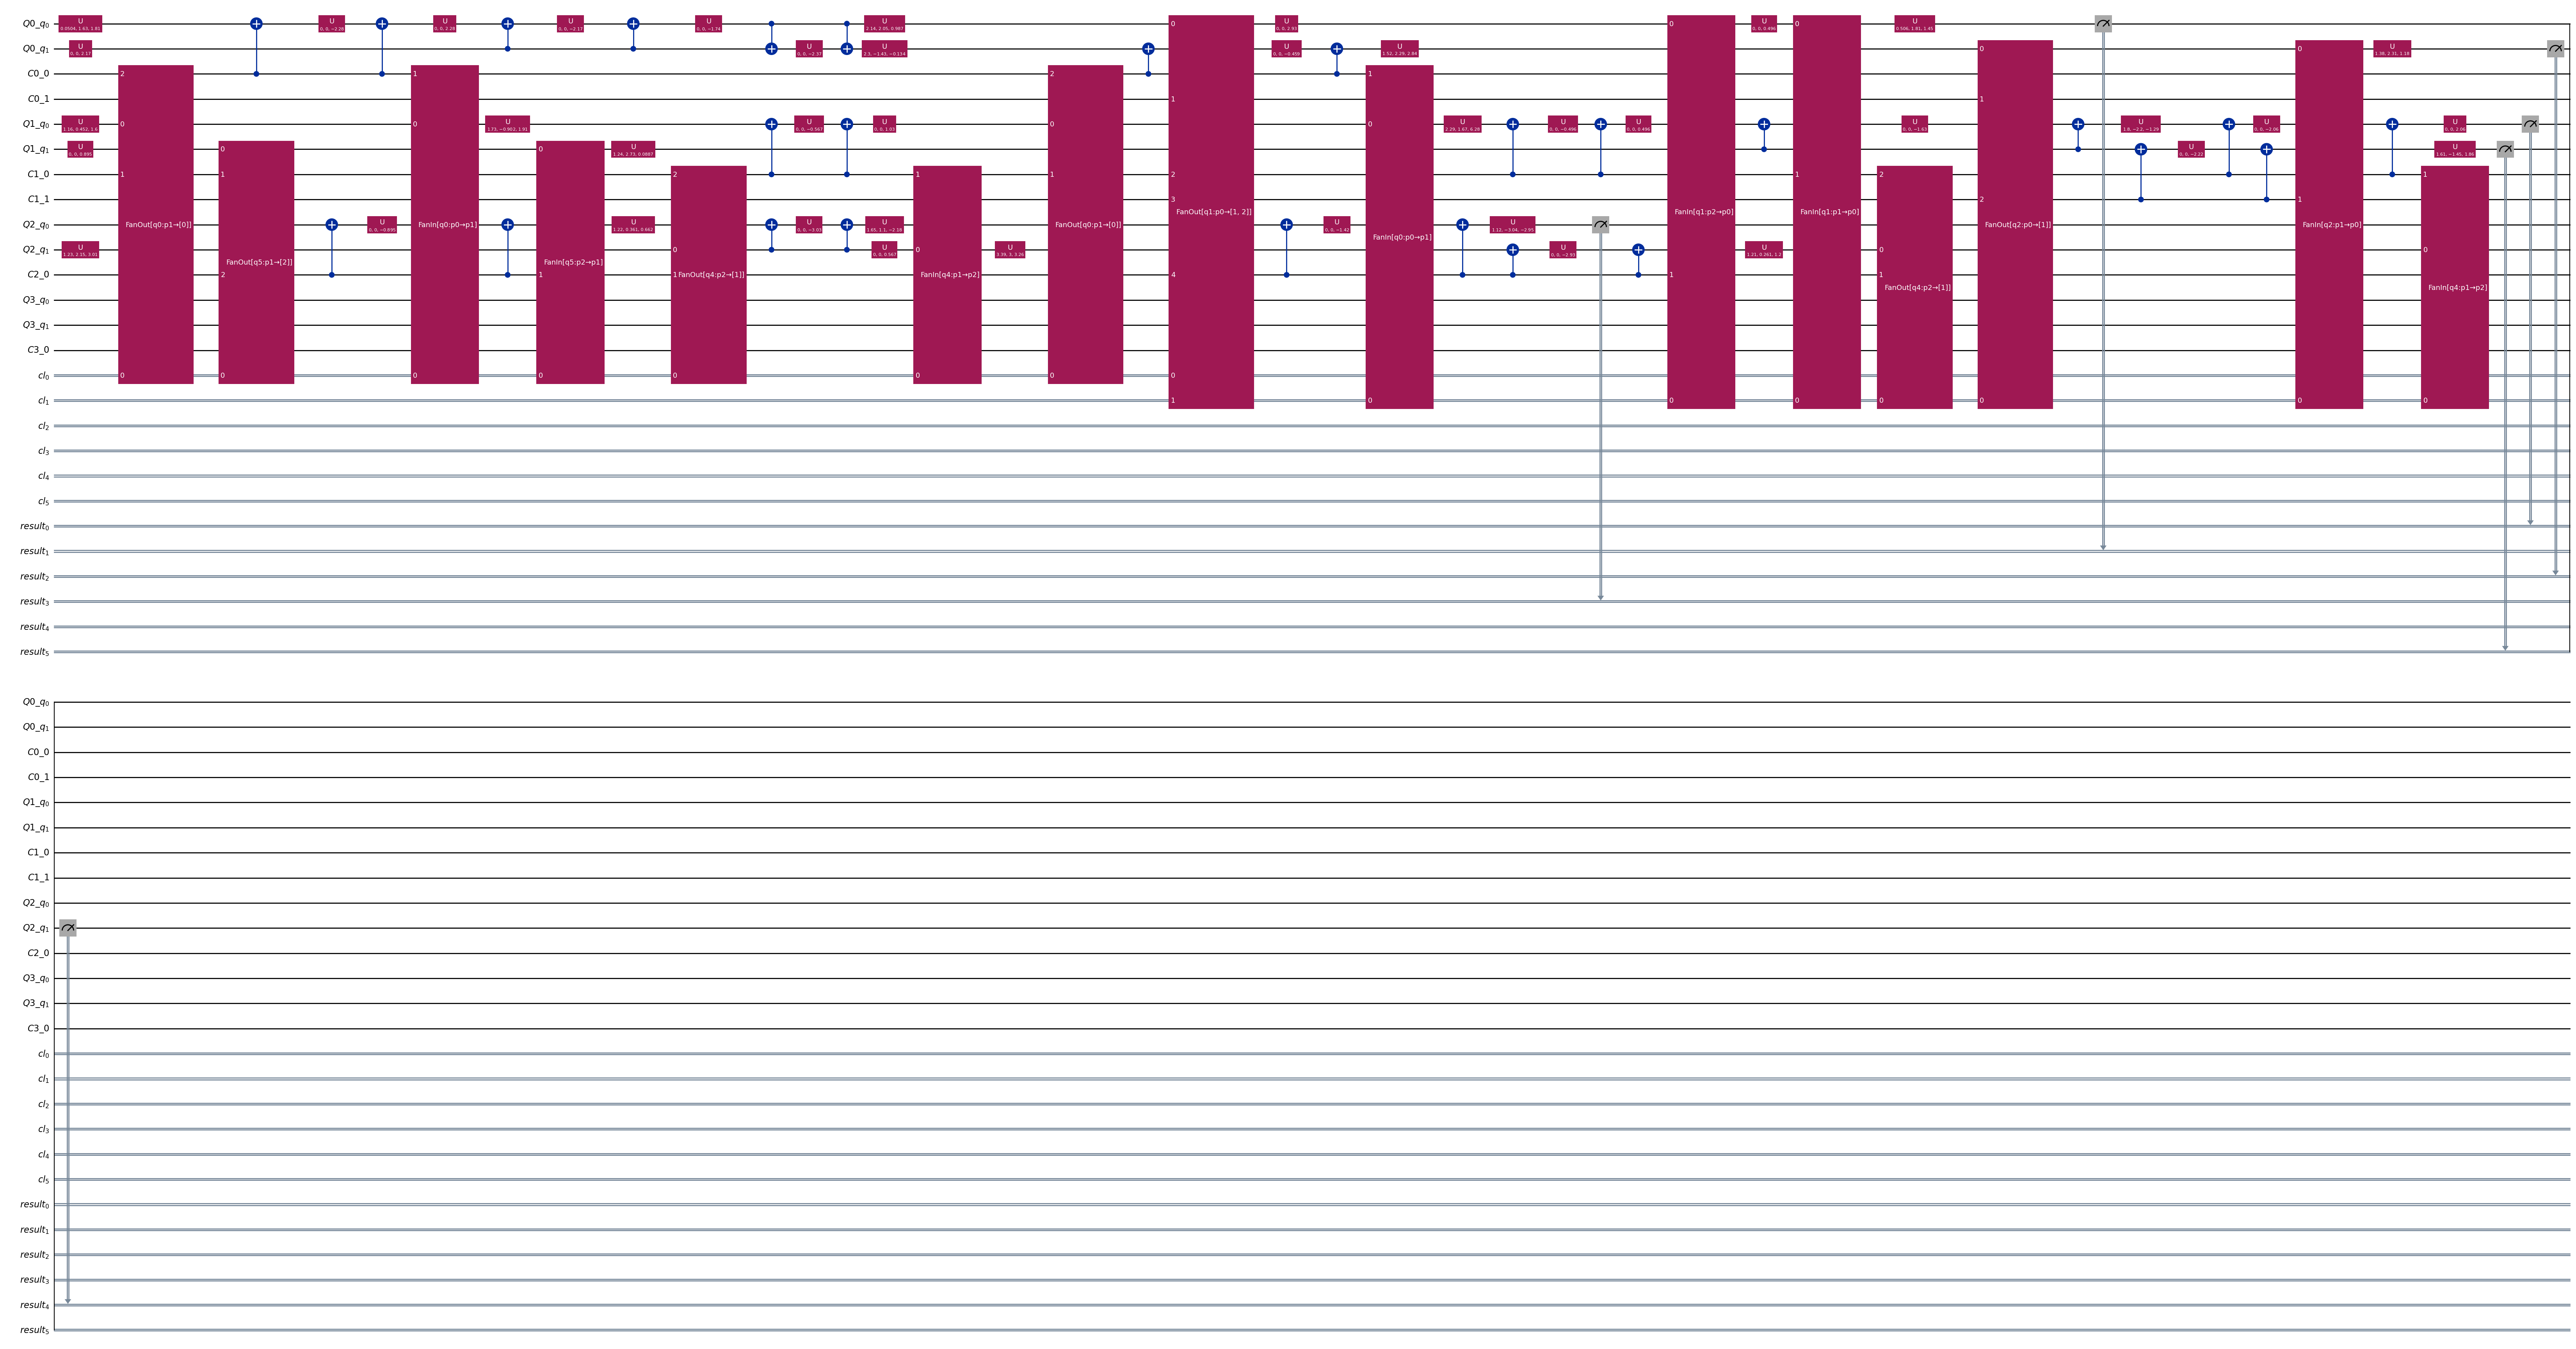

In [43]:
from disqco.circuit_extraction import DistributedCircuitToQiskit

lowerer = DistributedCircuitToQiskit(dc, qnet, assignment[0], compress_corrections=False)
dc_qiskit = lowerer.build()

print(f"DistributedCircuitToQiskit depth : {dc_qiskit.depth()}")
print()
print("High-level instruction blocks:")
for name, count in sorted(dc_qiskit.count_ops().items()):
    print(f"  {name:45s} x{count}")

dc_qiskit.draw('mpl', fold=100)

Equivalence check:
  depth — DistributedCircuitToQiskit : 32
  depth — PartitionedCircuitExtractor : 56
  EPR pairs — new  : 8
  EPR pairs — ref  : 8
EPR counts match.


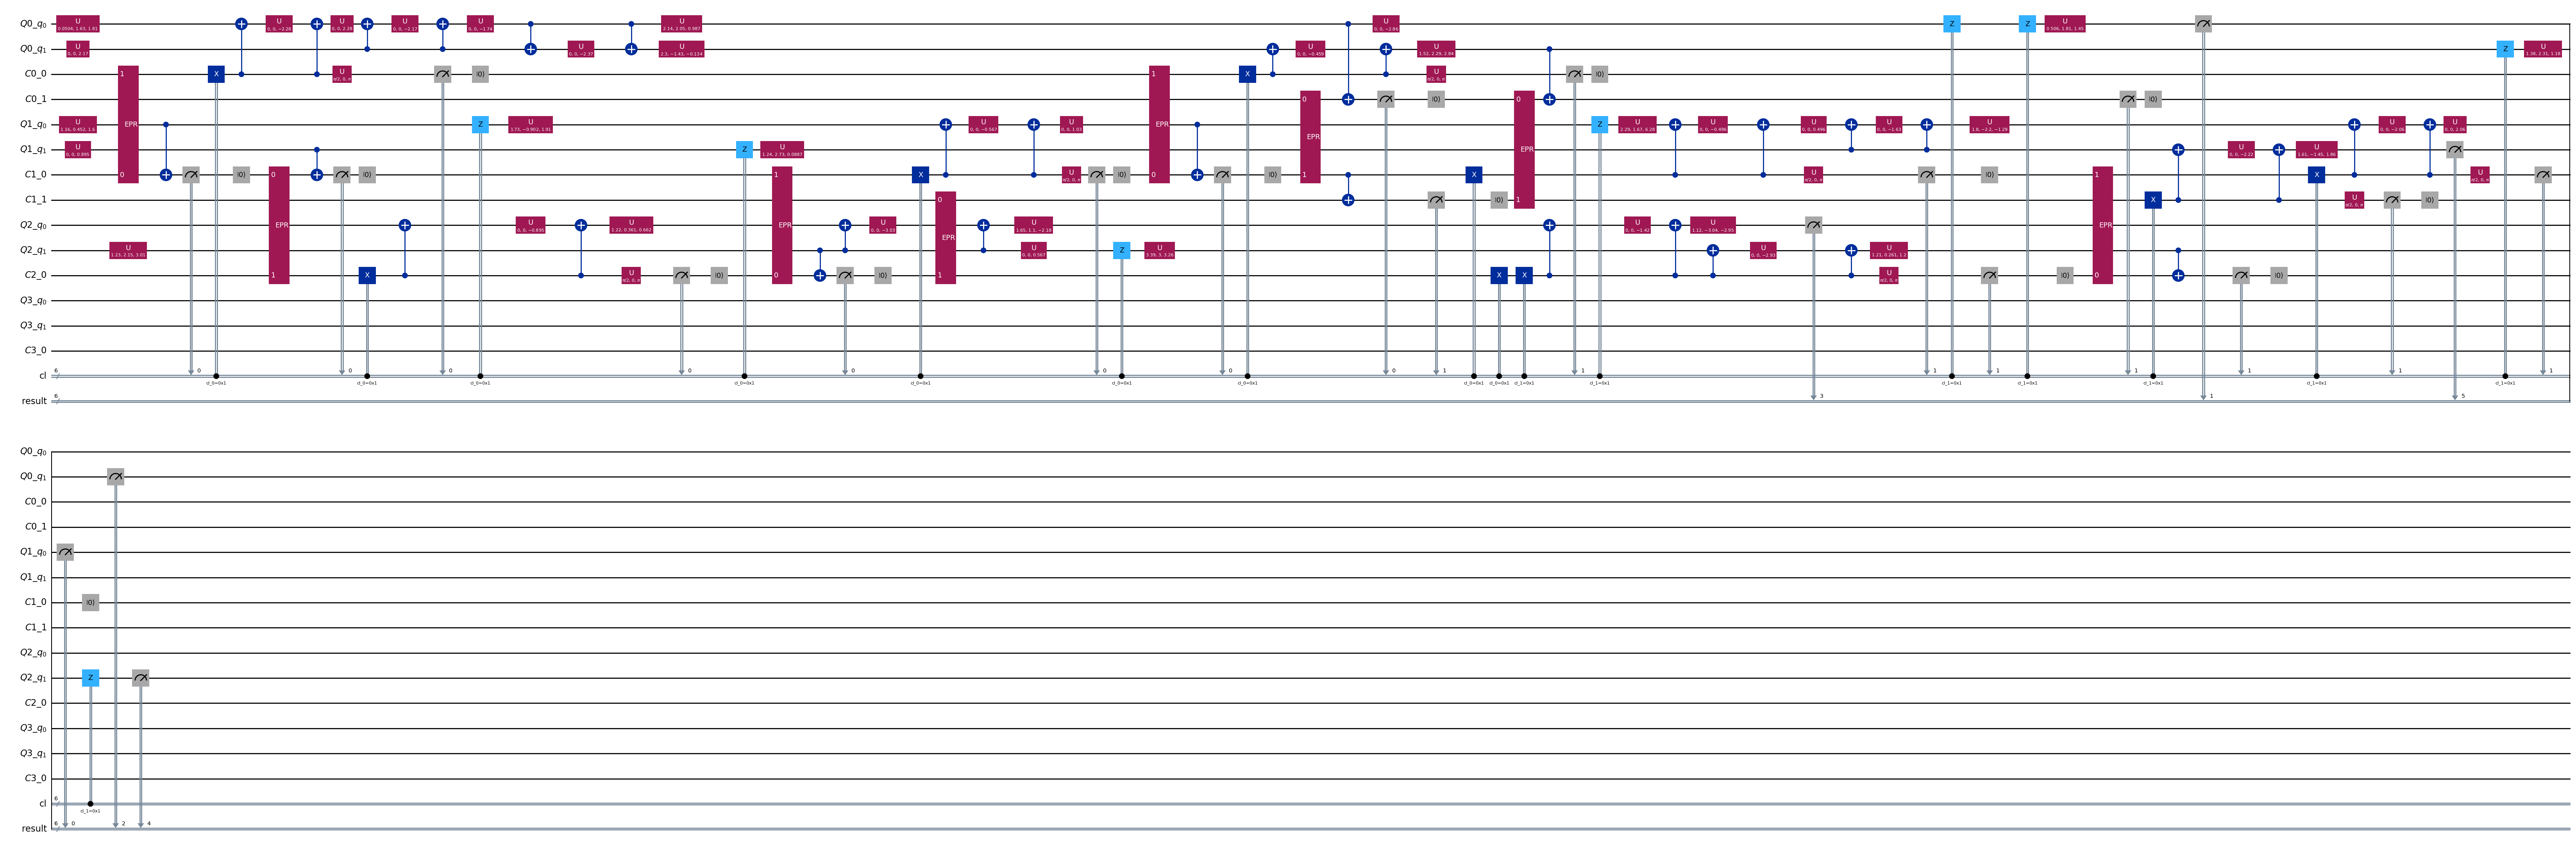

In [44]:
# Compare EPR counts between both extractors
def count_eprs(qc):
    tq = transpile(qc, basis_gates=['cp', 'u', 'EPR'])
    return tq.count_ops().get('EPR', 0)

epr_new = count_eprs(dc_qiskit)
epr_ref = count_eprs(qiskit_circuit)

print("Equivalence check:")
print(f"  depth — DistributedCircuitToQiskit : {dc_qiskit.depth()}")
print(f"  depth — PartitionedCircuitExtractor : {qiskit_circuit.depth()}")
print(f"  EPR pairs — new  : {epr_new}")
print(f"  EPR pairs — ref  : {epr_ref}")
assert epr_new == epr_ref, "EPR count mismatch!"
print("EPR counts match.")

qiskit_circuit.draw('mpl', fold=100)

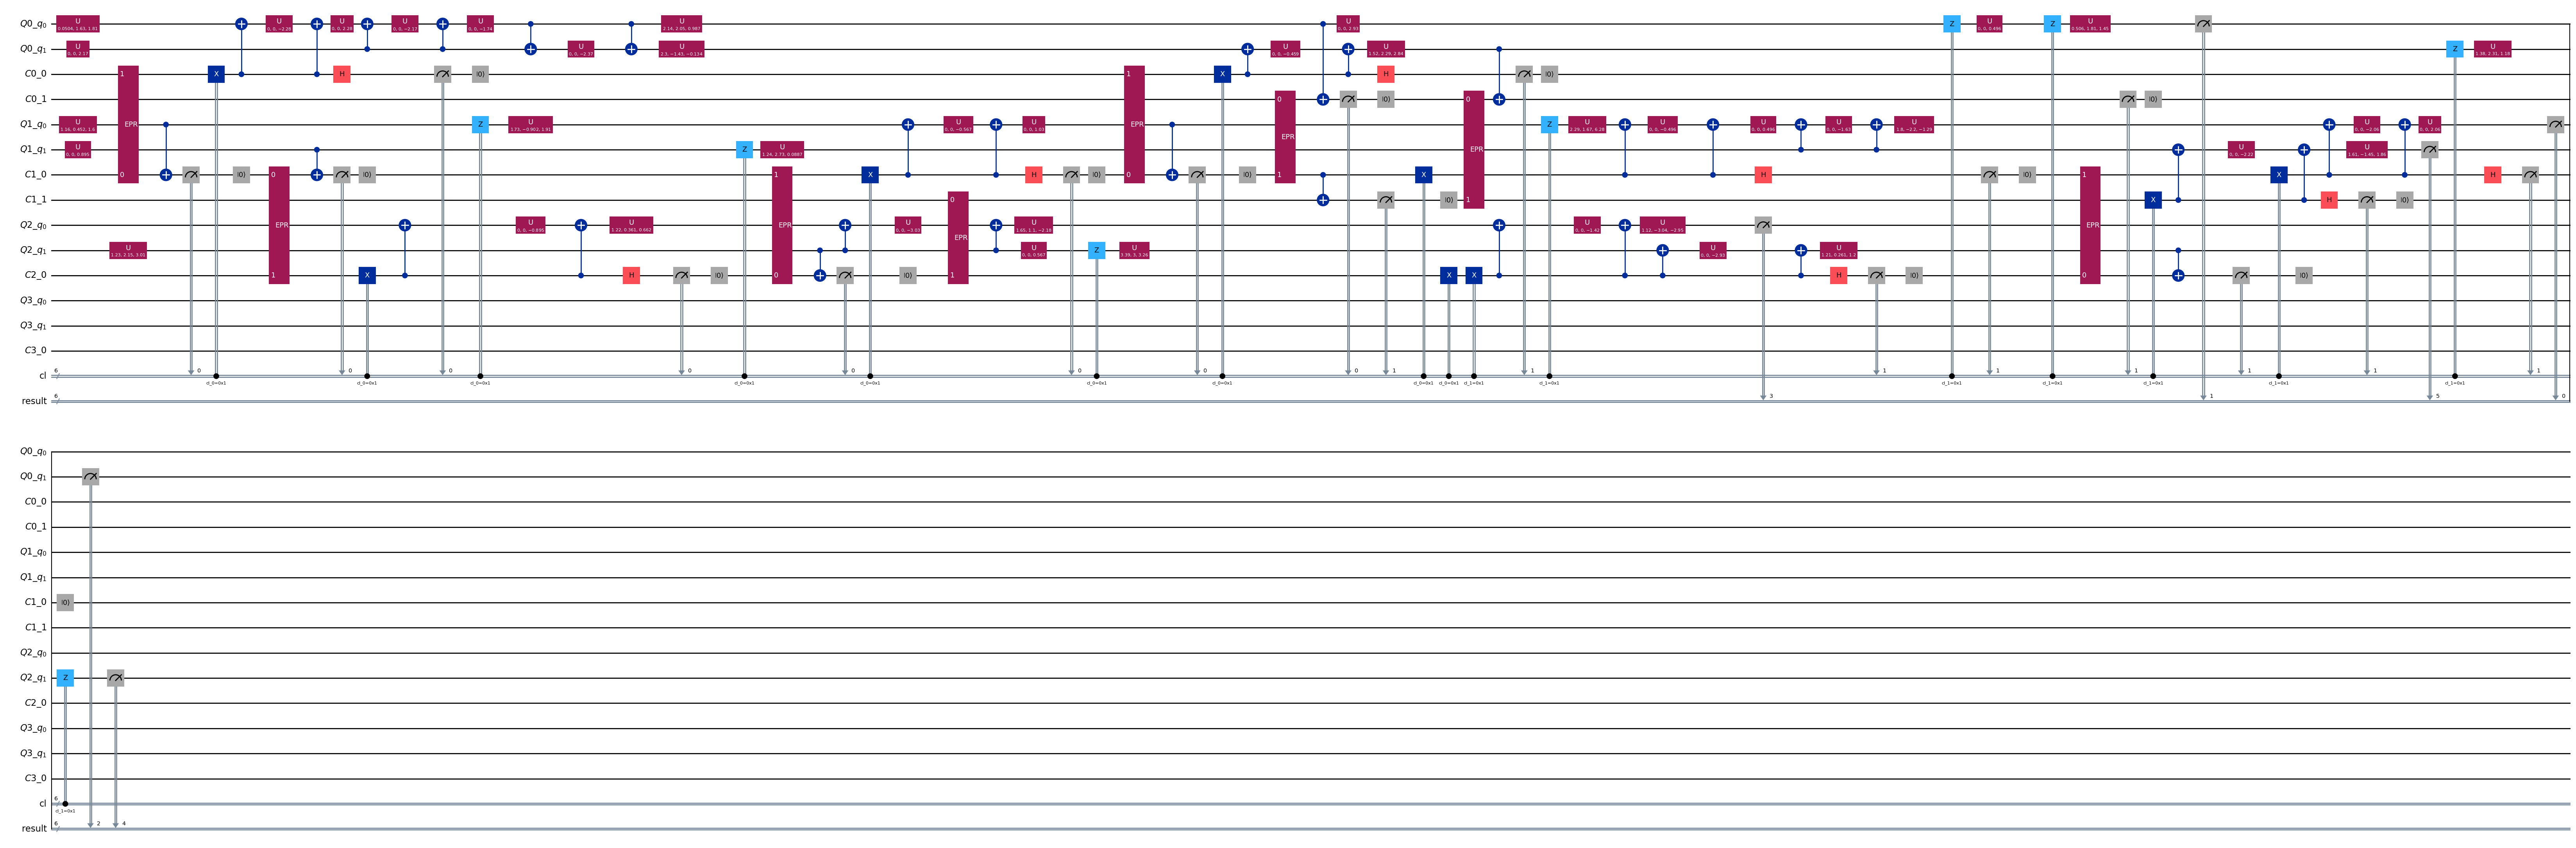

In [45]:
dc_qiskit.decompose().draw('mpl', fold=100)

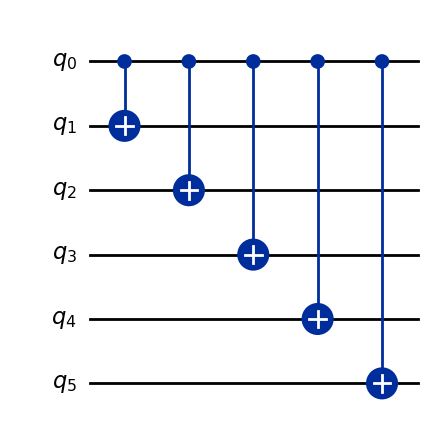

In [46]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(6)

circuit.cx(0, 1)
circuit.cx(0, 2)
circuit.cx(0, 3)
circuit.cx(0, 4)
circuit.cx(0, 5)

circuit.draw('mpl')



In [47]:
graph = QuantumCircuitHyperGraph(circuit=circuit, group_gates=True, anti_diag=True)

network = QuantumNetwork([2,2,2],qpu_connectivity=[(0,1), (1,2)])

In [48]:
assignment = set_initial_partition_assignment(graph=graph, network=network)

from disqco.circuit_extraction import HypergraphToDistributed

builder = HypergraphToDistributed(graph, network, assignment)
dc = builder.build()

print(dc.summary())

from disqco.drawing import DistributedCircuitQPIC

renderer = DistributedCircuitQPIC(dc)
qpic_str = renderer.to_qpic_string()
with open("fanout_test.qpic", "w") as f:
    f.write(qpic_str)

DistributedCircuit (6q, 3p):
  FanIn: 2
  FanOut: 1
  LinkedGate: 5


DistributedCircuitToQiskit depth : 6

High-level instruction blocks:
  FanIn[q0:p1→p0]                               x1
  FanIn[q0:p2→p0]                               x1
  FanOut[q0:p0→[1, 2]]                          x1
  cx                                            x5
  measure                                       x6


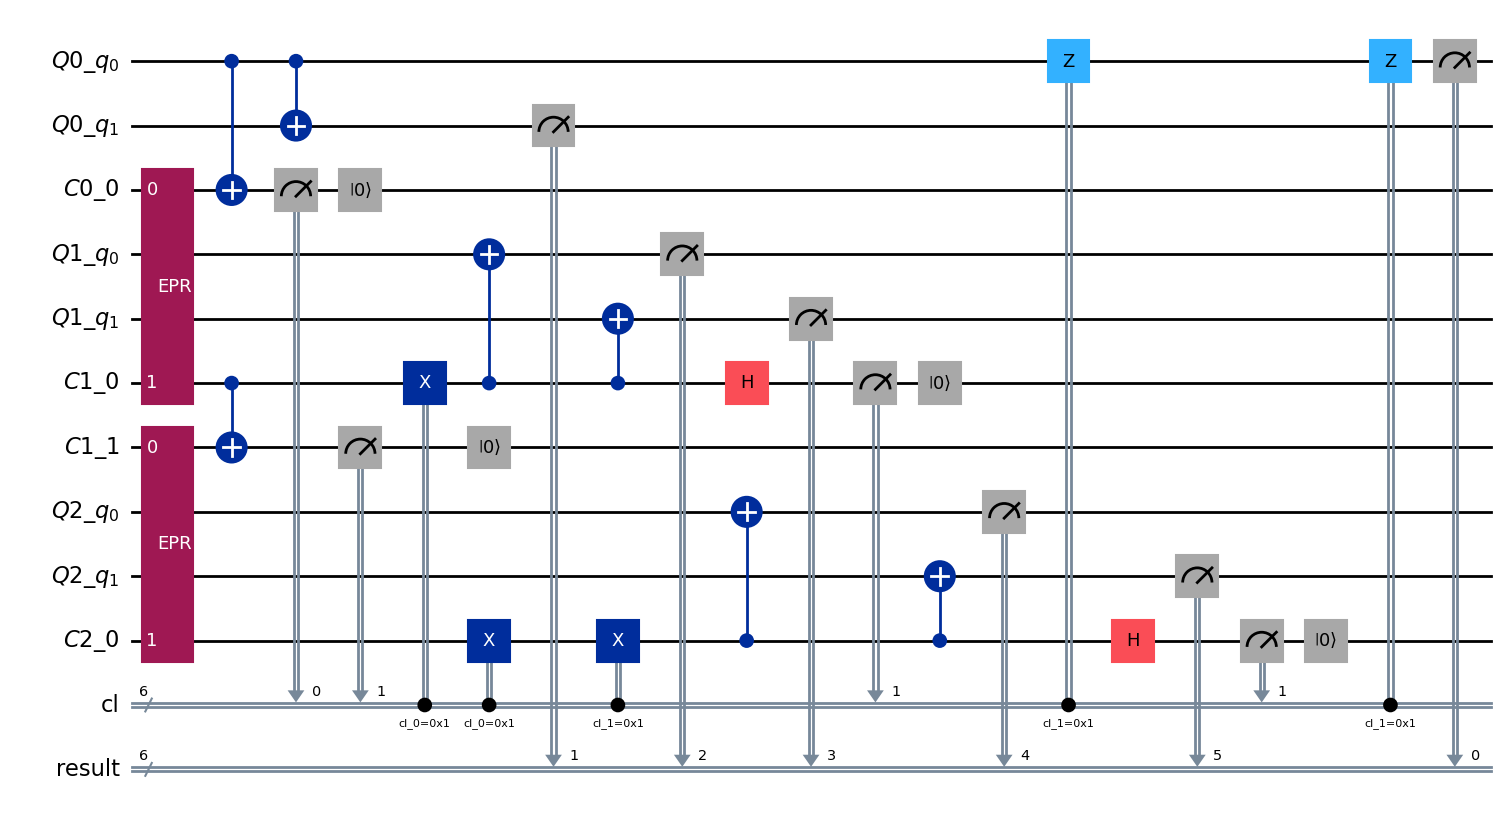

In [49]:
from disqco.circuit_extraction import DistributedCircuitToQiskit

lowerer = DistributedCircuitToQiskit(dc, network, assignment[0])
dc_qiskit = lowerer.build()

print(f"DistributedCircuitToQiskit depth : {dc_qiskit.depth()}")
print()
print("High-level instruction blocks:")
for name, count in sorted(dc_qiskit.count_ops().items()):
    print(f"  {name:45s} x{count}")

dc_qiskit.decompose().draw('mpl', fold=100)

In [50]:
# Rebuild DistributedCircuit after latest source changes and check FanOut stats
import importlib
import disqco.circuit_extraction.hypergraph_to_distributed as h2d_mod

importlib.reload(h2d_mod)
from disqco.circuit_extraction import HypergraphToDistributed, FanOut

dc_rebuilt = HypergraphToDistributed(graph, qnet, assignment).build()
fanouts = dc_rebuilt.get_events_by_type(FanOut)
empty_fanouts = [fo for fo in fanouts if not fo.target_partitions and not fo.intermediate_partitions]

print(f"FanOut events (rebuilt): {len(fanouts)}")
print(f"Empty FanOut events:     {len(empty_fanouts)}")

FanOut events (rebuilt): 1
Empty FanOut events:     0
